<a href="https://colab.research.google.com/github/pisceno/AI-Generative/blob/main/Grafo1024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Descargando y cargando grafo...

--- RESULTADO CLAVE ---
Tamaño del Conjunto Independiente (α(G) aprox.): 74
Tiempo de Ejecución: 0.1388 segundos

4. Generando Representación Visual (Muestra de 50 Vértices)...


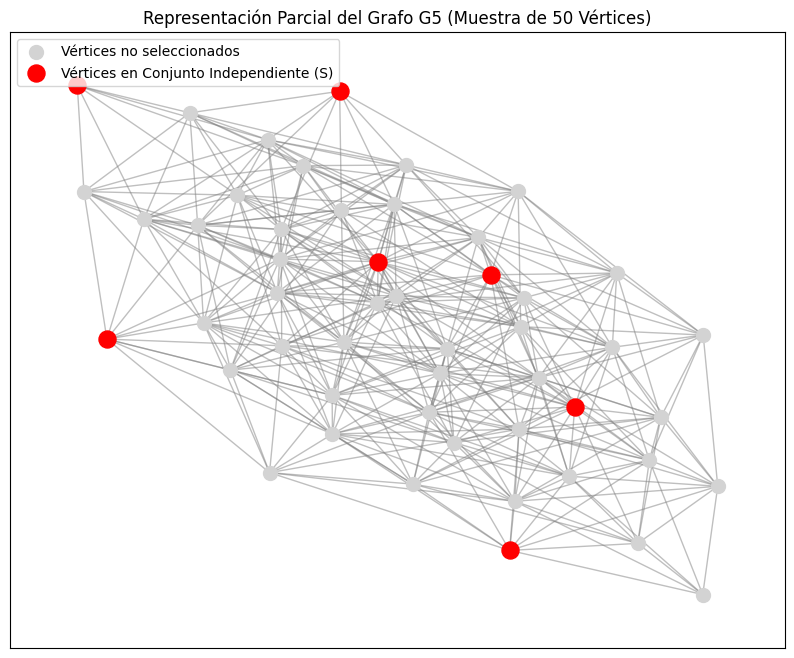

In [5]:
import collections
import time
import requests
import sys
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# --- CONFIGURACIÓN: URL RAW DE TU REPOSITORIO DE GITHUB ---
# -----------------------------------------------------------
github_raw_url = 'https://raw.githubusercontent.com/pisceno/data_sets/refs/heads/main/1dc.1024.txt'
file_path_local = '1dc.1024.txt'
# -----------------------------------------------------------

# --- FUNCIÓN 1: Lectura y Carga ---
def leer_grafo_dimacs(file_path):
    adj = collections.defaultdict(set)
    num_vertices = 0
    num_aristas = 0

    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line.startswith(('c', 'p', 'e')):
                    continue
                parts = line.split()
                if parts[0] == 'p':
                    num_vertices = int(parts[2])
                    num_aristas = int(parts[3])
                elif parts[0] == 'e':
                    u = int(parts[1])
                    v = int(parts[2])
                    adj[u].add(v)
                    adj[v].add(u)

        for i in range(1, num_vertices + 1):
            if i not in adj:
                adj[i] = set()

        return adj, num_vertices, num_aristas

    except Exception as e:
        print(f"Error durante la lectura del archivo DIMACS: {e}", file=sys.stderr)
        return None, 0, 0

def descargar_y_leer_grafo(url, local_path):
    print("1. Descargando y cargando grafo...")
    try:
        response = requests.get(url)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Error al descargar: {e}", file=sys.stderr)
        return None, 0, 0

    with open(local_path, 'w') as f:
        f.write(response.text)

    return leer_grafo_dimacs(local_path)

# --- FUNCIÓN 2: Heurística Greedy ---
def greedy_max_independent_set(adj, num_vertices):
    S = []
    V_restante = set(range(1, num_vertices + 1))
    start_time = time.time()

    while V_restante:
        grados_restantes = {}
        for v in V_restante:
            grado = len(adj[v].intersection(V_restante))
            grados_restantes[v] = grado

        try:
            v_min_grado = min(grados_restantes, key=grados_restantes.get)
        except ValueError:
            break

        S.append(v_min_grado)

        vecinos_a_remover = adj[v_min_grado].intersection(V_restante)
        a_remover = vecinos_a_remover | {v_min_grado}
        V_restante -= a_remover

    return S, time.time() - start_time

# --- FUNCIÓN 3: Visualización del Grafo (Muestra Reducida) ---
def visualizar_subgrafo(adj, independent_set, N):

    # Creamos un grafo de NetworkX a partir de tu lista de adyacencia
    G = nx.Graph(adj)

    # Solo visualizamos una muestra de 50 vértices para que sea legible
    muestra_vertices = list(range(1, 51))
    G_muestra = G.subgraph(muestra_vertices)

    # Identificamos los nodos que están en el Conjunto Independiente de la muestra
    nodos_en_S = [n for n in G_muestra.nodes() if n in independent_set]
    nodos_fuera_S = [n for n in G_muestra.nodes() if n not in independent_set]

    # 1. Definir la disposición de los nodos
    # Usamos spring_layout para que la representación parezca una red orgánica
    pos = nx.spring_layout(G_muestra, seed=42)

    plt.figure(figsize=(10, 8))
    plt.title(f"Representación Parcial del Grafo G5 (Muestra de 50 Vértices)")

    # 2. Dibujar todos los nodos
    # Dibujar nodos fuera del conjunto S (gris)
    nx.draw_networkx_nodes(G_muestra, pos,
                           nodelist=nodos_fuera_S,
                           node_color='lightgray',
                           node_size=100,
                           label='Vértices no seleccionados')

    # Dibujar nodos DENTRO del conjunto S (azul/rojo, tu selección)
    nx.draw_networkx_nodes(G_muestra, pos,
                           nodelist=nodos_en_S,
                           node_color='red',
                           node_size=150,
                           label='Vértices en Conjunto Independiente (S)')

    # 3. Dibujar las aristas
    nx.draw_networkx_edges(G_muestra, pos, alpha=0.5, edge_color='gray')

    plt.legend(scatterpoints=1, loc='upper left')
    plt.show()

# -----------------------------------------------------------
# --- EJECUCIÓN PRINCIPAL ---
# -----------------------------------------------------------

# 1. Cargar el grafo desde GitHub
grafo_adj, N, M = descargar_y_leer_grafo(github_raw_url, file_path_local)

if N > 0:
    # 2. Ejecutar la Heurística
    independent_set, tiempo = greedy_max_independent_set(grafo_adj, N)

    print(f"\n--- RESULTADO CLAVE ---")
    print(f"Tamaño del Conjunto Independiente (α(G) aprox.): {len(independent_set)}")
    print(f"Tiempo de Ejecución: {tiempo:.4f} segundos")

    # 3. Visualizar el Subgrafo
    print("\n4. Generando Representación Visual (Muestra de 50 Vértices)...")
    visualizar_subgrafo(grafo_adj, independent_set, N)

    # Añadir un recordatorio para tu explicación
    # El usuario puede usar esta imagen en su informe (Entregable 1, punto 4)

else:
    print("\nLa visualización falló porque el grafo no pudo ser cargado correctamente.")